# Part 0
- Data cleaning.
- Data transformation.
- The above are achieved by converting most data types to numerical .
- Also cleaning data is very important because the models expect numerical data not strings.


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

URL = "https://raw.githubusercontent.com/krishna-koly/IMDB_TOP_1000/refs/heads/main/imdb_top_1000.csv"
df = pd.read_csv(URL)
print(df.shape)
print(df.dtypes)

(1000, 16)
Poster_Link       object
Series_Title      object
Released_Year     object
Certificate       object
Runtime           object
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross             object
dtype: object


In [77]:
df_clean = df.copy()

df_clean['Runtime'] = pd.to_numeric(
    df_clean['Runtime'].str.replace(' min', '', regex=False), errors='coerce')
df_clean['Gross'] = pd.to_numeric(
    df_clean['Gross'].str.replace(',', '', regex=False), errors='coerce')
df_clean['Released_Year'] = pd.to_numeric(
    df_clean['Released_Year'], errors='coerce')

df_clean = df_clean.dropna(subset=['Released_Year'])
df_clean['Released_Year'] = df_clean['Released_Year'].astype(int)

missing = df_clean.isnull().sum()
print(missing[missing > 0])

Certificate    101
Meta_score     157
Gross          169
dtype: int64


*We check for which columns we remove outliers.*

In [78]:

numerical_cols = ['Released_Year', 'Runtime', 'IMDB_Rating', 
                  'Meta_score', 'No_of_Votes', 'Gross']

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    n = df_clean[(df_clean[col] < Q1 - 1.5*IQR) | 
                 (df_clean[col] > Q3 + 1.5*IQR)].shape[0]
    print(f"{col}: {n} outliers")

Released_Year: 7 outliers
Runtime: 29 outliers
IMDB_Rating: 13 outliers
Meta_score: 7 outliers
No_of_Votes: 67 outliers
Gross: 89 outliers


- *Outliers from No_of_votes and Gross will be removed as they have to many outliers.*
- *From here we take 2 separate datasets one for Linear regression and one for the tree based models.*
- **df_clean_linear for Linear Regression**
- **df_clean_full for Tree and RF**

In [79]:
df_clean_full = df_clean

Q1_v = df_clean['No_of_Votes'].quantile(0.25)
Q3_v = df_clean['No_of_Votes'].quantile(0.75)
IQR_v = Q3_v - Q1_v

Q1_g = df_clean['Gross'].quantile(0.25)
Q3_g = df_clean['Gross'].quantile(0.75)
IQR_g = Q3_g - Q1_g

outliers_votes = set(df_clean[(df_clean['No_of_Votes'] < Q1_v - 1.5*IQR_v) | 
                               (df_clean['No_of_Votes'] > Q3_v + 1.5*IQR_v)].index)

outliers_gross = set(df_clean[(df_clean['Gross'] < Q1_g - 1.5*IQR_g) | 
                               (df_clean['Gross'] > Q3_g + 1.5*IQR_g)].index)

all_outliers = outliers_votes | outliers_gross

print(f"No_of_Votes outliers: {len(outliers_votes)}")
print(f"Gross outliers:       {len(outliers_gross)}")
print(f"Overlap:              {len(outliers_votes & outliers_gross)}")
print(f"Total unique rows to remove: {len(all_outliers)}")

df_clean = df_clean.drop(index=all_outliers)
df_clean_linear = df_clean

print(f"Shape of linear after removal: {df_clean_linear.shape}")
print(f"Shape of full: {df_clean_full.shape}")

No_of_Votes outliers: 67
Gross outliers:       89
Overlap:              30
Total unique rows to remove: 126
Shape of linear after removal: (873, 16)
Shape of full: (999, 16)


In [80]:
df_clean_linear['Certificate'] = df_clean_linear['Certificate'].fillna('Unknown')
df_clean_full['Certificate'] = df_clean_full['Certificate'].fillna('Unknown')


for col in ['Meta_score', 'Gross']:
    df_clean_linear[col] = df_clean_linear[col].fillna(df_clean_linear[col].median())
    df_clean_full[col] = df_clean_full[col].fillna(df_clean_full[col].median())


print(f"Remaining NaNs: {df_clean_full.isnull().sum().sum()}, {df_clean_linear.isnull().sum().sum()}")

Remaining NaNs: 0, 0


In [81]:
def transform_certificate_genre_star_director(df_clean) :
    cert_map = {
        'G': 'Universal', 'U': 'Universal', 'PG': 'Universal',
        'GP': 'Universal', 'TV-PG': 'Universal', 'Passed': 'Universal',
        'Approved': 'Universal', 'UA': 'UnderSupervision',
        'U/A': 'UnderSupervision', 'PG-13': 'UnderSupervision',
        'TV-14': 'UnderSupervision', 'A': 'Adult', 'R': 'Adult',
        'TV-MA': 'Adult', 'Unrated': 'Adult', '16': 'Adult',
        'Unknown': 'Unknown'
    }
    df_clean['Certificate'] = df_clean['Certificate'].map(cert_map).fillna('Unknown')

    from sklearn.preprocessing import MultiLabelBinarizer

    df_clean['Genre_List'] = (df_clean['Genre']
        .str.split(',')
        .apply(lambda x: [g.strip() for g in x]))

    mlb = MultiLabelBinarizer()
    genre_encoded = pd.DataFrame(
        mlb.fit_transform(df_clean['Genre_List']),
        columns=[f'Genre_{g}' for g in mlb.classes_],
        index=df_clean.index
    )

    cert_encoded = pd.get_dummies(df_clean['Certificate'], prefix='Cert')

    director_counts = df_clean['Director'].value_counts()
    df_clean['Is_Prolific_Director'] = df_clean['Director'].map(
        lambda x: 1 if director_counts[x] >= 3 else 0)

    all_actors = pd.concat([df_clean['Star1'], df_clean['Star2'],
                            df_clean['Star3'], df_clean['Star4']])
    actor_counts = all_actors.value_counts()

    def has_prolific_actor(row):
        for col in ['Star1', 'Star2', 'Star3', 'Star4']:
            if actor_counts.get(row[col], 0) >= 3:
                return 1
        return 0

    df_clean['Is_Prolific_Actor'] = df_clean.apply(has_prolific_actor, axis=1)

    df_clean = pd.concat([df_clean, genre_encoded, cert_encoded], axis=1)

    cols_to_drop = ['Poster_Link', 'Overview', 'Genre', 'Genre_List',
                    'Certificate', 'Director', 'Star1', 'Star2', 'Star3', 'Star4',
                    'Series_Title']
    df_clean = df_clean.drop(columns=cols_to_drop)

    print(f"Shape: {df_clean.shape}")
    print(f"Remaining NaNs: {df_clean.isnull().sum().sum()}")
    print(df_clean.dtypes)
    
    return df_clean
    
df_clean_linear = transform_certificate_genre_star_director(df_clean_linear)
df_clean_full = transform_certificate_genre_star_director(df_clean_full)

Shape: (873, 33)
Remaining NaNs: 0
Released_Year              int64
Runtime                    int64
IMDB_Rating              float64
Meta_score               float64
No_of_Votes                int64
Gross                    float64
Is_Prolific_Director       int64
Is_Prolific_Actor          int64
Genre_Action               int64
Genre_Adventure            int64
Genre_Animation            int64
Genre_Biography            int64
Genre_Comedy               int64
Genre_Crime                int64
Genre_Drama                int64
Genre_Family               int64
Genre_Fantasy              int64
Genre_Film-Noir            int64
Genre_History              int64
Genre_Horror               int64
Genre_Music                int64
Genre_Musical              int64
Genre_Mystery              int64
Genre_Romance              int64
Genre_Sci-Fi               int64
Genre_Sport                int64
Genre_Thriller             int64
Genre_War                  int64
Genre_Western              int64
Cert_Adu

In [82]:
df_clean_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Released_Year          999 non-null    int64  
 1   Runtime                999 non-null    int64  
 2   IMDB_Rating            999 non-null    float64
 3   Meta_score             999 non-null    float64
 4   No_of_Votes            999 non-null    int64  
 5   Gross                  999 non-null    float64
 6   Is_Prolific_Director   999 non-null    int64  
 7   Is_Prolific_Actor      999 non-null    int64  
 8   Genre_Action           999 non-null    int64  
 9   Genre_Adventure        999 non-null    int64  
 10  Genre_Animation        999 non-null    int64  
 11  Genre_Biography        999 non-null    int64  
 12  Genre_Comedy           999 non-null    int64  
 13  Genre_Crime            999 non-null    int64  
 14  Genre_Drama            999 non-null    int64  
 15  Genre_Famil

In [83]:
def fix_from_bool_to_int (df_clean) :
    
    cert_cols = [col for col in df_clean.columns if col.startswith('Cert_')]
    df_clean[cert_cols] = df_clean[cert_cols].astype(int)

    print(df_clean[cert_cols].dtypes)
    return df_clean

df_clean_full = fix_from_bool_to_int(df_clean_full)
df_clean_linear = fix_from_bool_to_int(df_clean_linear)

Cert_Adult               int64
Cert_UnderSupervision    int64
Cert_Universal           int64
Cert_Unknown             int64
dtype: object
Cert_Adult               int64
Cert_UnderSupervision    int64
Cert_Universal           int64
Cert_Unknown             int64
dtype: object


# **Part1** What feature we choose based on a correlation matrix .

- The reasoning here is that we find the column that has the most correlation with all other 
columns therefore making it easiest to determine based on the other columns.
- We do this by creating a correlation matrix and summing the absolute values for each column.

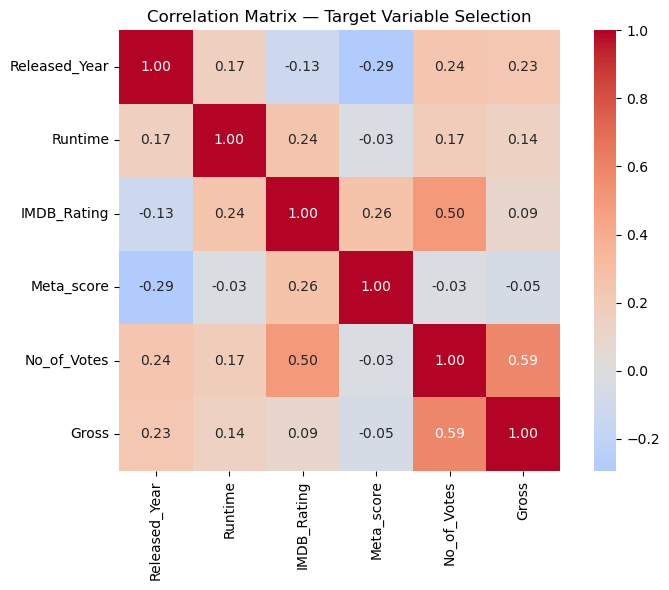

Total absolute correlation with other features:
No_of_Votes      1.526
IMDB_Rating      1.216
Gross            1.098
Released_Year    1.065
Runtime          0.747
Meta_score       0.658
dtype: float64


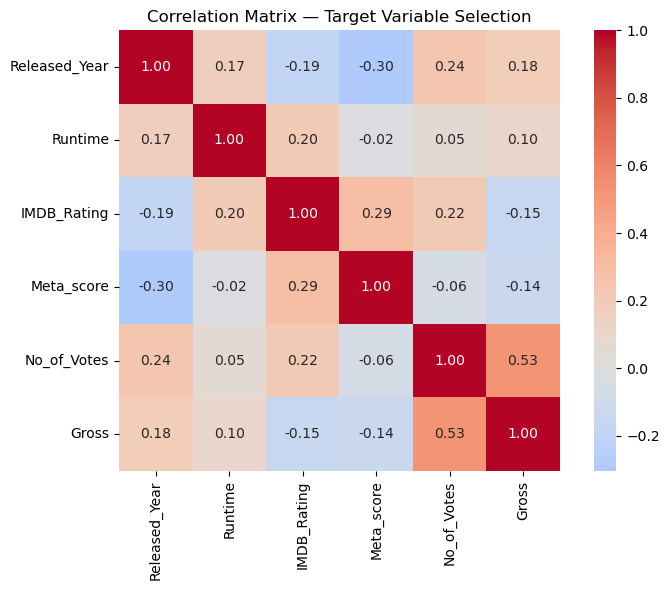

Total absolute correlation with other features:
No_of_Votes      1.097
Gross            1.092
Released_Year    1.084
IMDB_Rating      1.042
Meta_score       0.807
Runtime          0.550
dtype: float64


In [84]:
def correlation_matrix(df_clean) :

    numerical_cols = ['Released_Year', 'Runtime', 'IMDB_Rating', 
                    'Meta_score', 'No_of_Votes', 'Gross']

    corr_matrix = df_clean[numerical_cols].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, square=True)
    plt.title('Correlation Matrix — Target Variable Selection')
    plt.tight_layout()
    plt.show()

    # Sum of absolute correlations per column (excluding self-correlation)
    corr_sums = corr_matrix.abs().sum() - 1  
    corr_sums = corr_sums.sort_values(ascending=False)
    print("Total absolute correlation with other features:")
    print(corr_sums.round(3))
    
correlation_matrix(df_clean_full)
correlation_matrix(df_clean_linear)

**Decision**
- based on the fact that for both the linear and full dataset we get
- the No_of_votes has the highest score makes the decision for the label
- an easy one .

 # Part2
 - Relevant features will be selected also based on the correlation matrix already done above.
 - The logarization of the label(target variable) is important since it removes the skewness.
 - As we observe most movies are clustered from(Vote counts POV) at the lower end (Logarization solves this by uniforming the distribution).
 - Based on abs feature correlation with new log label the columns get filtered for training and testing.

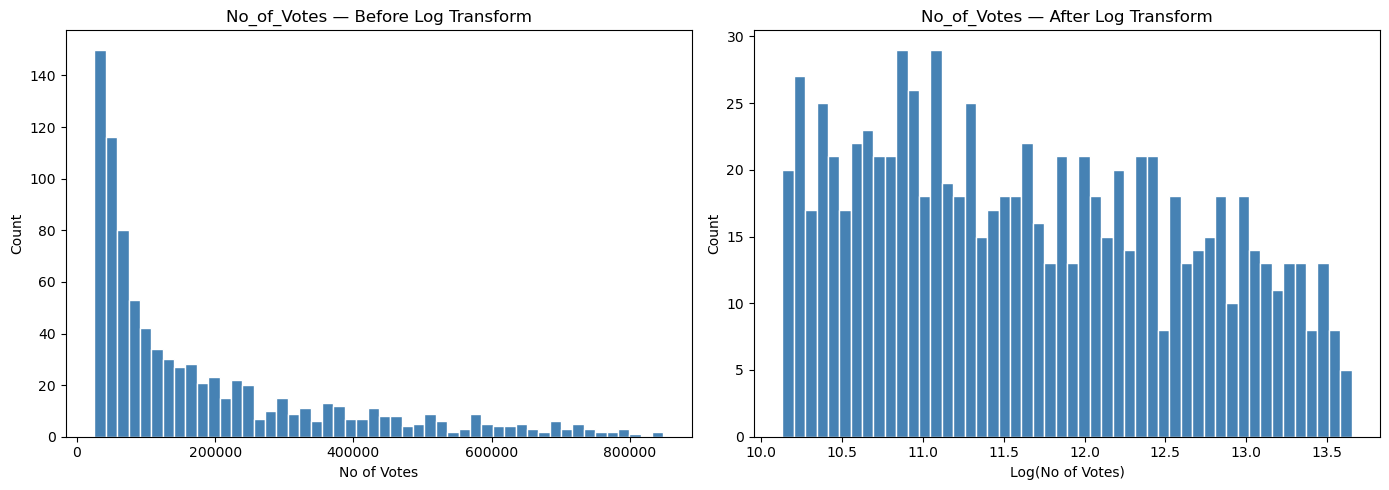

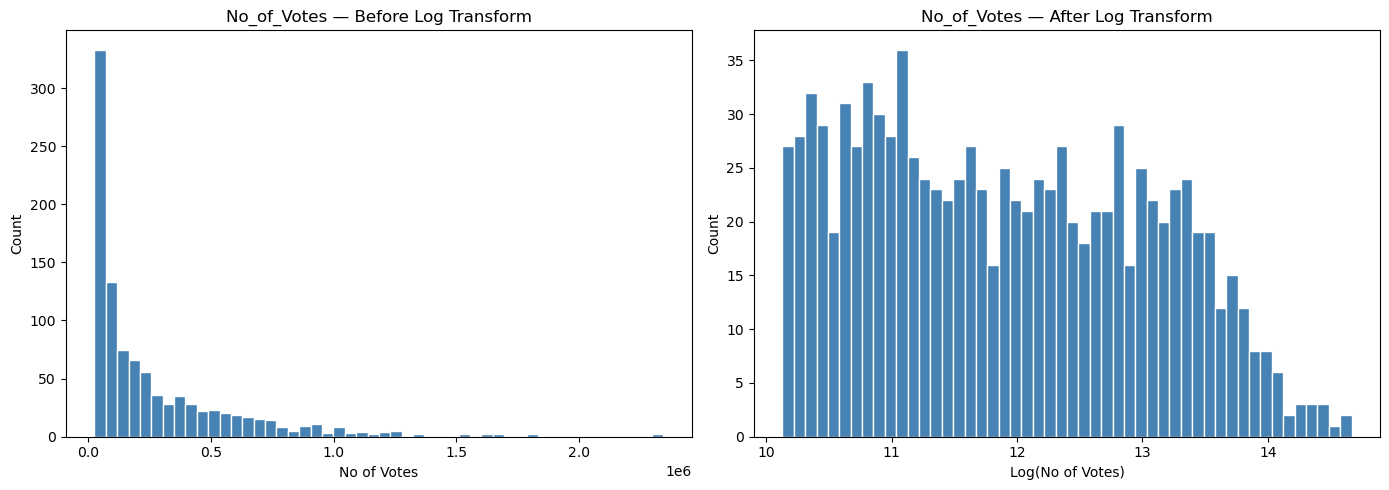

In [85]:
def logaritmize_votes(df_clean) :
    df_clean['Log_Votes'] = np.log1p(df_clean['No_of_Votes'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(df_clean['No_of_Votes'], bins=50, 
                color='steelblue', edgecolor='white')
    axes[0].set_title('No_of_Votes — Before Log Transform')
    axes[0].set_xlabel('No of Votes')
    axes[0].set_ylabel('Count')

    axes[1].hist(df_clean['Log_Votes'], bins=50,
                color='steelblue', edgecolor='white')
    axes[1].set_title('No_of_Votes — After Log Transform')
    axes[1].set_xlabel('Log(No of Votes)')
    axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

logaritmize_votes(df_clean_linear)
logaritmize_votes(df_clean_full)

* Different view on the feature correlation part with the new logartimized label.

C:\Users\Mihai\AppData\Local\Temp\ipykernel_25024\1545051954.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='muted')


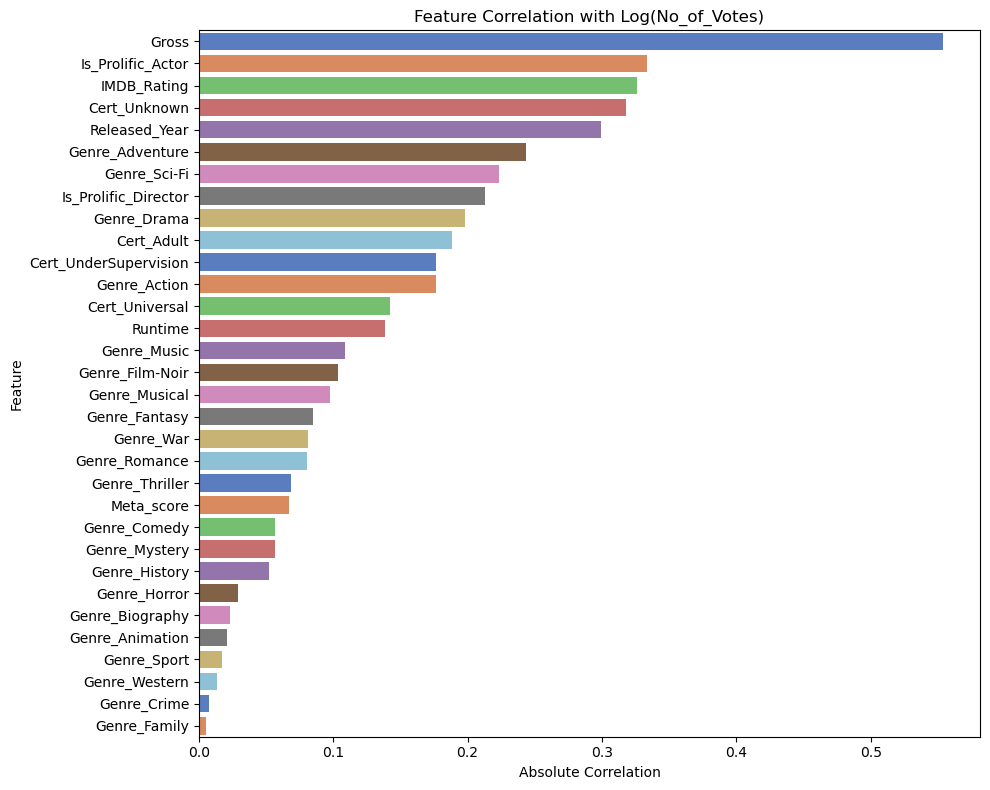

C:\Users\Mihai\AppData\Local\Temp\ipykernel_25024\1545051954.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='muted')


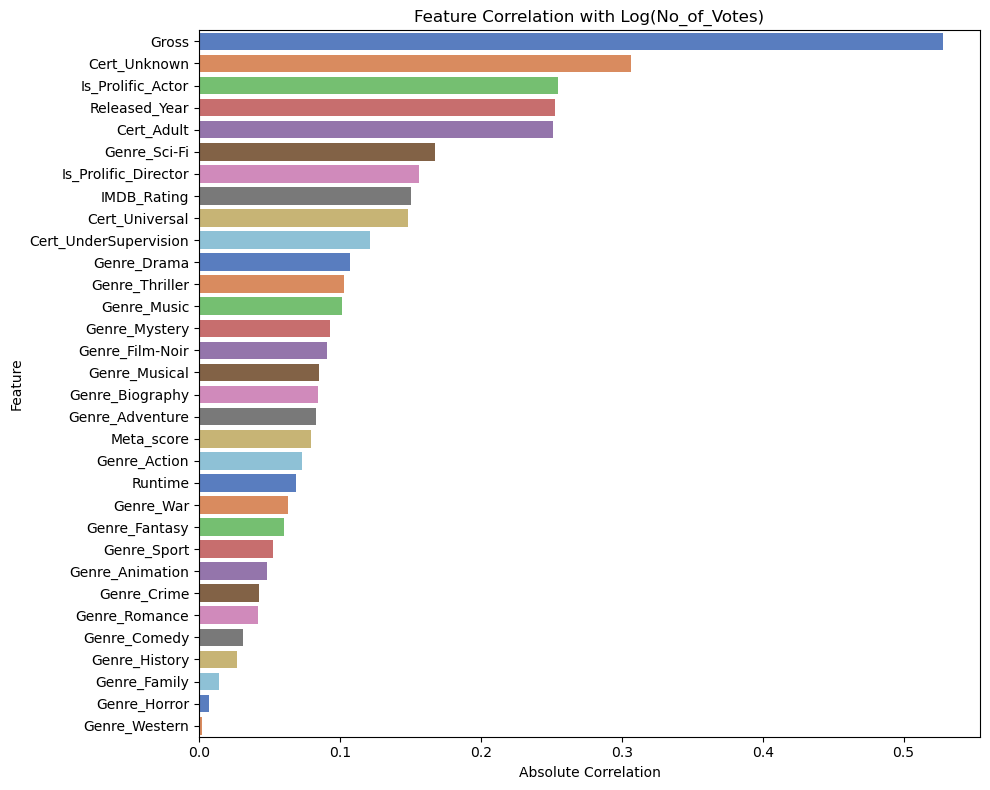

In [87]:
def feature_correlation(df_clean) :

    feature_cols = [col for col in df_clean.columns 
                    if col not in ['No_of_Votes', 'Log_Votes']]

    corr_with_target = df_clean[feature_cols].corrwith(df_clean['Log_Votes'])
    corr_with_target = corr_with_target.abs().sort_values(ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='muted')
    plt.title('Feature Correlation with Log(No_of_Votes)')
    plt.xlabel('Absolute Correlation')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
    
    return corr_with_target
    
feature_correlation(df_clean_full)
corr_with_target = feature_correlation(df_clean_linear)

* Have chosen to keep all features that have at least an abs correlation above
* 0.10 as they are not plenty in number but also not few (We would have way less for 0.30 or 0.20)
* Here it can be tested with multiple values (0.05, 0.15, 0.20) and see best cross validated.

In [88]:
threshold = 0.10

selected_features = corr_with_target[corr_with_target >= threshold].index.tolist()

print(f"Selected features ({len(selected_features)}):")
for f in selected_features:
    print(f"  {f:<30} r={corr_with_target[f]:.3f}")

Selected features (13):
  Gross                          r=0.528
  Cert_Unknown                   r=0.307
  Is_Prolific_Actor              r=0.255
  Released_Year                  r=0.253
  Cert_Adult                     r=0.251
  Genre_Sci-Fi                   r=0.167
  Is_Prolific_Director           r=0.156
  IMDB_Rating                    r=0.151
  Cert_Universal                 r=0.148
  Cert_UnderSupervision          r=0.121
  Genre_Drama                    r=0.107
  Genre_Thriller                 r=0.103
  Genre_Music                    r=0.101


In [89]:
X = df_clean_linear[selected_features]
y = df_clean_linear['Log_Votes']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set:   {X_train.shape}")
print(f"Test set:       {X_test.shape}")

Training set:   (698, 13)
Test set:       (175, 13)


* Very important standartization is done such that features bear the sane importance no matter their unit and also
* it is easier from a computational point of view .
* This is done for LinearRegression based on the backbone of how the algorithm works
* Decision Tree and RandomForest do not need this.

In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled.shape)

(698, 13)


# Part 3 - Training and Testing
- Here training and testing is done for our finetuned dataset on the 3 regression models
- For decision tree and random forest multiple hyperparameters are tried.

In [91]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"Linear Regression:")
print(f"RMSE:{rmse_lr}")
print(f"MAE:{mae_lr}")
print(f"R²:{r2_lr}")

Linear Regression:
RMSE:0.6406837191877762
MAE:0.5154042447779942
R²:0.5234797817116024


In [98]:
tree_features = [col for col in df_clean_full.columns if col != 'Log_Votes' and col != 'No_of_Votes']
# print(tree_features)
X = df_clean_full[tree_features]
y = df_clean_full['Log_Votes']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set:   {X_train.shape}")
print(f"Test set:       {X_test.shape}")

Training set:   (799, 32)
Test set:       (200, 32)


In [99]:
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': [3, 5, 7, 10, 15, 20, None],
              'min_samples_split': [2, 5, 10, 20, 50],
              'min_samples_leaf': [1, 2, 4, 8, 16]}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV R²: {grid_search.best_score_:.4f}")

dt_best = grid_search.best_estimator_
y_pred_dt = dt_best.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt  = mean_absolute_error(y_test, y_pred_dt)
r2_dt   = r2_score(y_test, y_pred_dt)

print(f"\nDecision Tree (tuned):")
print(f"  RMSE: {rmse_dt:.4f}")
print(f"  MAE:  {mae_dt:.4f}")
print(f"  R²:   {r2_dt:.4f}")

Best parameters: {'max_depth': 15, 'min_samples_leaf': 8, 'min_samples_split': 2}
Best CV R²: 0.6097

Decision Tree (tuned):
  RMSE: 0.6638
  MAE:  0.5025
  R²:   0.6161


In [102]:
from sklearn.ensemble import RandomForestRegressor

param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 15, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8]
}

grid_search_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search_rf.fit(X_train, y_train)

print(f"Best parameters: {grid_search_rf.best_params_}")
print(f"Best CV R²: {grid_search_rf.best_score_:.4f}")

rf_best = grid_search_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest (tuned):")
print(f"  RMSE: {rmse_rf:.4f}")
print(f"  MAE:  {mae_rf:.4f}")
print(f"  R²:   {r2_rf:.4f}")

Best parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R²: 0.7555

Random Forest (tuned):
  RMSE: 0.5606
  MAE:  0.4205
  R²:   0.7262


            Model   RMSE    MAE     R²
Linear Regression 0.6407 0.5154 0.5235
    Decision Tree 0.6638 0.5025 0.6161
    Random Forest 0.5606 0.4205 0.7262


C:\Users\Mihai\AppData\Local\Temp\ipykernel_25024\3637718802.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results, palette='muted', ax=ax)
C:\Users\Mihai\AppData\Local\Temp\ipykernel_25024\3637718802.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results, palette='muted', ax=ax)
C:\Users\Mihai\AppData\Local\Temp\ipykernel_25024\3637718802.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results, palette='muted', ax=ax)


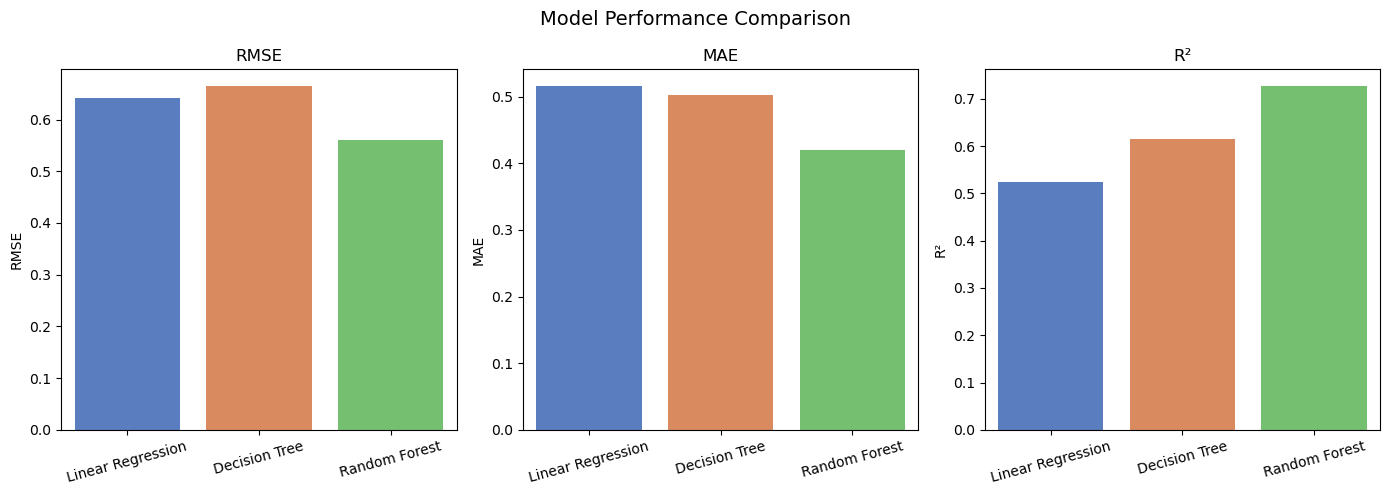

In [101]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'RMSE':  [rmse_lr, rmse_dt, rmse_rf],
    'MAE':   [mae_lr,  mae_dt,  mae_rf],
    'R²':    [r2_lr,   r2_dt,   r2_rf]
})

print(results.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    sns.barplot(x='Model', y=metric, data=results, palette='muted', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Performance Comparison', fontsize=14)
plt.tight_layout()
plt.show()

**Part4**


C:\Users\Mihai\AppData\Local\Temp\ipykernel_25024\1728102484.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dt_importance.values, y=dt_importance.index,
C:\Users\Mihai\AppData\Local\Temp\ipykernel_25024\1728102484.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importance.values, y=rf_importance.index,


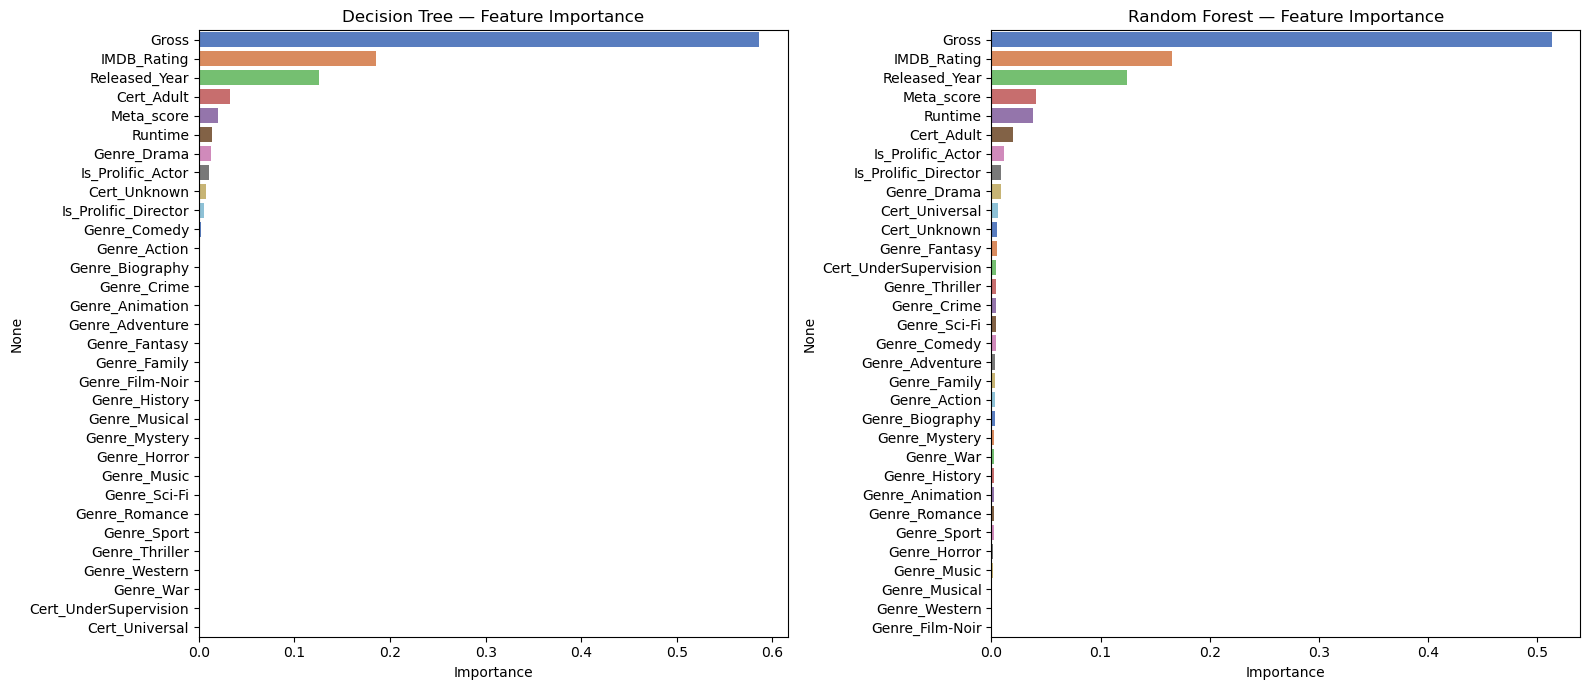

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

dt_importance = pd.Series(
    dt_best.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

sns.barplot(x=dt_importance.values, y=dt_importance.index, 
            palette='muted', ax=axes[0])
axes[0].set_title('Decision Tree — Feature Importance')
axes[0].set_xlabel('Importance')

rf_importance = pd.Series(
    rf_best.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

sns.barplot(x=rf_importance.values, y=rf_importance.index,
            palette='muted', ax=axes[1])
axes[1].set_title('Random Forest — Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()